In [52]:
import requests
import os
from dotenv import load_dotenv
from itertools import combinations
from collections import Counter
import networkx as nx
import json
from networkx.readwrite import json_graph
import netwulf as nw
import matplotlib.pyplot as plt
from datetime import datetime
from pathlib import Path
from tqdm import tqdm
from tqdm.contrib.concurrent import thread_map
import matplotlib as mpl
from matplotlib import colors as mpl_colors
from collections import Counter, defaultdict
from matplotlib.lines import Line2D

# Get cinema‑released movies from TMDb

In [4]:
DATA_DIR = Path("projectAB_data")
DATA_DIR.mkdir(exist_ok=True)

load_dotenv()
API_KEY = os.getenv("TMDB_API_KEY")

BASE = "https://api.themoviedb.org/3/discover/movie"

params = {
    "api_key": API_KEY,
    "with_release_type": 3,
    "sort_by": "popularity.desc",
    "primary_release_date.gte": "2000-01-01",
}

# -- Pagination --

DATA_FILE = DATA_DIR / "movies_raw.json"

if DATA_FILE.exists():
    with open(DATA_FILE, "r") as f:
        all_movies = json.load(f)
    print("Loaded movies from disk")
else:
    all_movies = []
    for page in tqdm(range(1, 6), desc="Fetching movie pages"): # first 5 pages = 100 movies
        params["page"] = page
        r_movies = requests.get(BASE, params=params).json()
        all_movies.extend(r_movies["results"])

        # Save checkpoint after each page
        with open(DATA_FILE, "w") as f:
            json.dump(all_movies, f, indent=2)


Fetching movie pages: 100%|██████████| 5/5 [00:04<00:00,  1.16it/s]


In [ ]:
# Extract movie Titles
titles = [ m.get("title") for m in all_movies]
titles

['The Super Mario Galaxy Movie',
 'Your Heart Will Be Broken',
 'Avatar: Aang, The Last Airbender',
 'Avatar: Fire and Ash',
 'The Mortuary Assistant',
 'Project Hail Mary',
 'Hoppers',
 'Thrash',
 'Sex with Love',
 'Balls Up',
 'Shelter',
 'Greenland 2: Migration',
 'Sniper: No Nation',
 'Send Help',
 'The Super Mario Bros. Movie',
 "Lee Cronin's The Mummy",
 'Crime 101',
 'GOAT',
 'Scream 7',
 'Demon Slayer: Kimetsu no Yaiba Infinity Castle',
 'The Strangers: Chapter 3',
 'undertone',
 'The Yeti',
 'War Machine',
 'Zootopia 2',
 'Mudborn',
 'The Housemaid',
 'Outcome',
 'The Unknown Man',
 'The Bride!',
 'Return to Silent Hill',
 'War of the Worlds',
 'Whistle',
 'Vengeance',
 'Anaconda',
 'Spider-Man: No Way Home',
 'Humint',
 'Pretty Lethal',
 'Ready or Not: Here I Come',
 'The Devil Wears Prada',
 'Mike & Nick & Nick & Alice',
 'Starbright',
 '"Wuthering Heights"',
 "The Shadow's Edge",
 'Roommates',
 'Reminders of Him',
 'Interstellar',
 'The Intouchables',
 'The House on Haunted

In [29]:
print("Number of movies fetched:", len(titles))

Number of movies fetched: 100


In [34]:
# Extract movie IDs and Titles as tuples of (ID, Title, Popularity, Vote avg, Vote count, Release date, Original language)
movies = {
    m["id"]: {
        "title": m.get("title"),
        "popularity": m.get("popularity"),
        "vote_avg": m.get("vote_average"),
        "vote_count": m.get("vote_count"),
        "release_date": m.get("release_date"),
        "original_language": m.get("original_language"),
    }
    for m in all_movies
}
movies[350]

{'title': 'The Devil Wears Prada',
 'popularity': 105.3256,
 'vote_avg': 7.4,
 'vote_count': 12949,
 'release_date': '2006-06-29',
 'original_language': 'en'}

# Get actors for each movie

In [35]:
CREDITS_DIR = DATA_DIR / "credits" # Directory for saving the credits of each movie
CREDITS_DIR.mkdir(exist_ok=True)

# API contact to get credits for 1 movie by its ID
def fetch_credits(movie_id):
    out_file = CREDITS_DIR / f"{movie_id}.json"

    # If already saved, load from disk
    if out_file.exists():
        with open(out_file, "r") as f:
            return movie_id, json.load(f)

    # Otherwise, fetch from API
    url = f"https://api.themoviedb.org/3/movie/{movie_id}/credits"
    params = {"api_key": API_KEY}
    r = requests.get(url, params=params)
    r.raise_for_status()
    data = r.json()

    # Save the API response
    with open(out_file, "w") as f:
        json.dump(data, f, indent=2)

    return movie_id, data


# Generate a list of movie IDs
movie_ids = [movie["id"] for movie in all_movies]

# Parallel process retrieving movie credits from the API
results = thread_map(
    fetch_credits,
    movie_ids,
    max_workers=8,
    desc="Fetching credits"
)

credits_by_movie = {}

for movie_id, r_cast in results:
    top_cast = sorted(
        r_cast.get("cast", []),
        key=lambda x: x["order"]
    )[:10]

    credits_by_movie[movie_id] = {
        "id": movie_id,
        "cast": [
            {
                "actor_id": a["id"],
                "name": a["name"],
                "order": a["order"]
            }
            for a in top_cast
        ]
    }

print(f"{len(list(CREDITS_DIR.glob("*.json")))} out of {len(all_movies)} movie's credits saved successfully.")

Fetching credits: 100%|██████████| 100/100 [00:00<00:00, 698.99it/s]


100 out of 100 movie's credits saved successfully.


In [40]:
print("Title:", movies[350]["title"])

credits_by_movie[350]

Title: The Devil Wears Prada


{'id': 350,
 'cast': [{'actor_id': 5064, 'name': 'Meryl Streep', 'order': 0},
  {'actor_id': 1813, 'name': 'Anne Hathaway', 'order': 1},
  {'actor_id': 5081, 'name': 'Emily Blunt', 'order': 2},
  {'actor_id': 2283, 'name': 'Stanley Tucci', 'order': 3},
  {'actor_id': 1284159, 'name': 'Simon Baker', 'order': 4},
  {'actor_id': 5090, 'name': 'Adrian Grenier', 'order': 5},
  {'actor_id': 10580, 'name': 'Tracie Thoms', 'order': 6},
  {'actor_id': 10581, 'name': 'Rich Sommer', 'order': 7},
  {'actor_id': 10582, 'name': 'Daniel Sunjata', 'order': 8},
  {'actor_id': 24535, 'name': 'David Marshall Grant', 'order': 9}]}

# Build the actor co‑starring network

In [41]:
# Build graph containing actors ID as nodes and their names as an attribute.
G = nx.Graph()
pair_counts = Counter()

for movie in credits_by_movie.values():
    cast = movie["cast"]
    actor_ids = []

    for a in cast:
        actor_id = a["actor_id"]

        actor_attrs = {
            "display_name": a["name"]
        }

        # Add node with attributes
        G.add_node(actor_id, **actor_attrs)

        actor_ids.append(actor_id)

    # Build co-starring edges
    for a, b in combinations(sorted(actor_ids), 2):
        pair_counts[(a, b)] += 1

In [42]:
# Weigh edges between actors by number of co-starring movies
Wedgelist = [(a, b, w) for (a, b), w in pair_counts.items()]
G.add_weighted_edges_from(Wedgelist)
Wedgelist[:5]


# Save JSON
data = json_graph.node_link_data(G)
with open(f"ActorGraph.json", "w") as f:
    json.dump(data, f, indent=2, default=int)

In [73]:
# Read graph from .json file
with open("ActorGraph.json") as f:
    data = json.load(f)

data["links"] = data.pop("edges")

# G = json_graph.node_link_graph(data, edges='edges')



# ---- Actor -> Language mapping based on most common original language ----
actor_languages = defaultdict(list)

for movie_id, credit in credits_by_movie.items():
    lang = movies[movie_id].get("original_language", "NA")

    for actor in credit["cast"]:
        actor_id = actor["actor_id"]
        actor_languages[actor_id].append(lang)

# Reduce to a single (most common) language per actor
actor_main_language = {}

for actor_id, langs in actor_languages.items():
    actor_main_language[actor_id] = Counter(langs).most_common(1)[0][0]

# ------------------------------------------


# ---- AUTO‑COLOR ALL country_code VALUES ----
codes = [
    actor_main_language.get(node["id"], "NA")
    for node in data["nodes"]
]
unique_codes = sorted(set(codes))
num_codes = len(unique_codes)

# choose a categorical colormap
cmap = mpl.colormaps["tab20"]

# sample N distinct colors from the colormap
color_list = [mpl_colors.to_hex(cmap(i / num_codes)) for i in range(num_codes)]

# build code → color mapping
code_to_color = dict(zip(unique_codes, color_list))

# assign colors to nodes
for node in data["nodes"]:
    actor_id = node["id"]
    lang = actor_main_language.get(actor_id, "NA")
    node["color"] = code_to_color.get(lang, "#7f7f7f")
# ------------------------------------------


network, config = nw.visualize(data, plot_in_cell_below=False)

# Tell Netwulf to use node["color"]
config["node_fill_color"] = "color"

# -- Save network and config to avoid LONG render times in the browser
with open(f"ActorNetwork.json", "w") as nfile:
    json.dump(network, nfile)

with open(f"ActorConfig.json", "w") as cfile:
    json.dump(config, cfile)

In [74]:
language_counts = Counter(actor_main_language.values())
top_langs = [lang for lang, _ in language_counts.most_common(10)]

legend_elements = [
    Line2D(
        [0], [0],
        marker='o',
        color='w',
        label=lang,
        markerfacecolor=code_to_color[lang],
        markersize=10
    )
    for lang in top_langs
]

2026-04-20_15-37-22


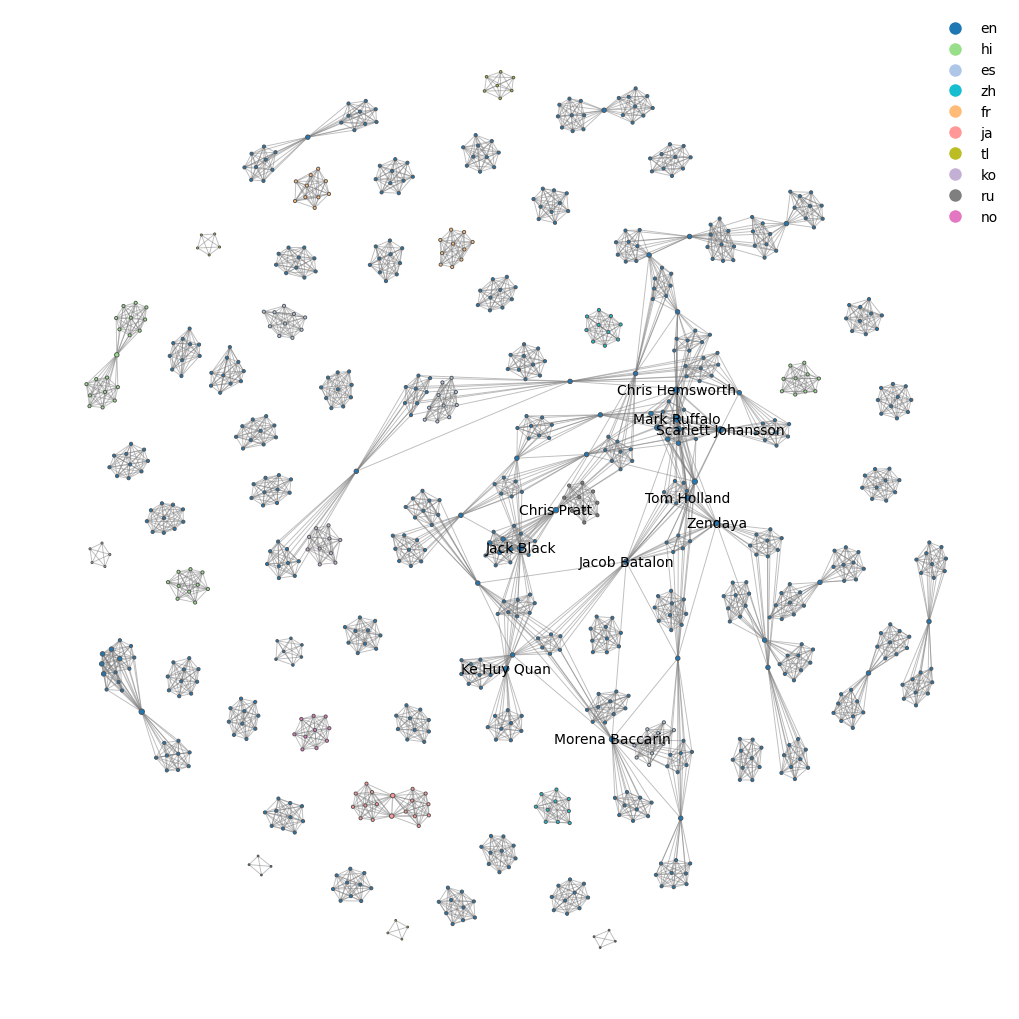

In [79]:
# draw links first
fig, ax = nw.draw_netwulf(network, figsize=10, draw_nodes=True)

top10 = sorted(G.degree(), key=lambda x: x[1], reverse=True)[0:10]
top10ids = [id for id, _ in top10]

for node in data["nodes"]:
    if node["id"] in top10ids: # Add names of top 5 authors by degree
        nw.add_node_label(ax, network, node["id"], node["display_name"])

# Add legend
ax.legend(
    handles=legend_elements,
    # title="Original language (actor-level)",
    loc="upper right",
    frameon=False
)

# Save the assortativity values
timestamp = datetime.now().strftime("%Y-%m-%d_%H-%M-%S")
print(timestamp)
plt.savefig(f"images/ActorNetworkGraph_{timestamp}.pdf")